In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from mpl_toolkits.mplot3d import Axes3D
from abc import ABC, abstractmethod
import math
import re
from scipy.optimize import minimize
from itertools import product
import seaborn as sns
from matplotlib import animation

# Define force field

In [2]:
def harmonic_PE(r, k, r0):
    """
    Computes harmonic potential energy

    Parameters:
        r: separation distance
        k: spring constant
        r0: equilibrium bond length

    Returns:
        Harmonic potential energy
    """
    return 0.5 * k * ((r-r0)**2)

def harmonic_force(r_vec, k, r0):
    """
    Computes the magnitude of the force due to the harmonic bond potential.

    Parameters:
        r_vec: displacement vector
        k: spring constant
        r0: equilibrium bond length

    Returns:
        Magnitude of the force due to the harmonic bond potential
    """
    r = np.linalg.norm(r_vec)
    r = np.clip(r, a_min=1e-12, a_max=None)
    return -k * (r-r0) * r_vec / r

well_coeff = 2**(1/6)
def repulsive_lj(r, sigma, epsilon):
    """
    Computes the repulsive Lennard-Jones potential energy.

    Parameters:
        r: separation distance
        sigma: distance where the potential energy is 0
        epsilon: well depth

    Returns:
        lj potential energy
    """
    if r < well_coeff*sigma:
        r = np.clip(r, a_min=1e-12, a_max=None)
        sixth_pow = (sigma/r) ** 6
        return 4 * epsilon * (sixth_pow**2 - sixth_pow + 1/4)
    else:
        return 0

def repulsive_lj_force(r_vec, sigma, epsilon):
    """
    Computes the force due to repulsive Lennard-Jones potential energy.

    Parameters:
        r_vec: displacement vector
        sigma: distance where the potential energy is 0
        epsilon: well depth

    Returns:
        force due to lj potential energy
    """
    r = np.linalg.norm(r_vec)
    if r < well_coeff*sigma:
        r = np.clip(r, a_min=1e-12, a_max=None)
        sixth_pow = (sigma/r) ** 6
        return -24*epsilon/r * (sixth_pow - 2*(sixth_pow**2)) * r_vec / r
    else:
        return np.zeros_like(r_vec)

def attractive_lj(r, sigma, epsilon):
    """
    Computes the attractive Lennard-Jones potential energy.

    Parameters:
        r: separation distance
        sigma: distance where the potential energy is 0
        epsilon: well depth

    Returns:
        lj potential energy
    """
    r = np.clip(r, a_min=1e-12, a_max=None)
    sixth_pow = (sigma/r) ** 6
    return 4 * epsilon * (sixth_pow**2 - sixth_pow)

def attractive_lj_force(r_vec, sigma, epsilon):
    """
    Computes the force due to attractive Lennard-Jones potential energy.

    Parameters:
        r_vec: displacement vector
        sigma: distance where the potential energy is 0
        epsilon: well depth

    Returns:
        force due to lj potential energy
    """
    r = np.linalg.norm(r_vec)
    r = np.clip(r, a_min=1e-12, a_max=None)
    sixth_pow = (sigma/r) ** 6
    return -24*epsilon/r * (sixth_pow - 2*(sixth_pow**2)) * r_vec / r

# Unit cell

In [3]:
class OrthorhombicCell():
    """
    Stores particle information in a orthorombic cell
    with periodic boundary conditions and minimum image convention
    """
    def __init__(self, a, b, c, n, masses, connectivity):
        """
        OrthorhombicCell(a, b, c, n, connectivity)

        Parameters:
            a, b, c: parameters of the cell
            n: number of particles in the cell
            masses: masses of particles
            connectivity:
                adjacency list of the bond connectivity of the particles.
                connectivity[i] is the list of indices for atoms bonded to atom i (0-based index)
        """
        self.dim = np.array([a, b, c])
        self.n = n
        self.masses = masses
        self.adj_list = connectivity
        self.positions = np.zeros((n, 3))
        self.bonded = None
        self.repulsive = None
        self.attractive = None
        # map of two-bond connectivity
        adj_list_2 = []
        for i in range(self.n):
            cur_list = []
            neighbors = self.adj_list[i]
            for neighbor in neighbors:
                for second_neighbor in self.adj_list[neighbor]:
                    if second_neighbor != i and second_neighbor not in neighbors:
                        cur_list.append(second_neighbor)
            adj_list_2.append(cur_list)
        self.adj_list_2 = adj_list_2

    def set_positions(self, positions):
        """
        Sets the positions of the atoms.

        Parameters:
            positions: np.array with shape self.n * 3
        """
        np.copyto(self.positions, positions)
    
    def wrap(self):
        """
        Wraps the particles into the cell by applying the pbc
        """
        self.positions %= self.dim

    def update_positions(self, delta_positions):
        """
        Add delta_positions to current positions and wrap in cell.

        Parameters:
            delta_positions: np.array with shape self.n * 3
        """
        self.positions += delta_positions
        self.wrap()

    def get_displacement_from_i_to_j(self, i, j):
        """
        Calculates displacement from atoms i to atom j with mic

        Parameters:
            i, j: int|array, indices of atoms

        Returns:
            An array of displacement vectors from atoms i to j under mic
        """
        r_vec = self.positions[j] - self.positions[i]
        r_mic = r_vec - self.dim*np.round(r_vec/self.dim)
        if r_mic.ndim == 1:
            r_mic = r_mic.reshape(1, -1)
        return r_mic

    def get_distances_between(self, i, j):
        """
        Calculates distance between atoms i and j with mic

        Parameters:
            i, j: int|array, indices of atoms

        Returns:
            An array of distances between atoms i and j under mic
        """
        r_mic = self.get_displacement_from_i_to_j(i, j)
        return np.linalg.norm(r_mic, axis=1)

    def unwrap(self):
        """
        Unwraps the particles onto the infinite lattice space
        by sequentially placing bonded atoms onto their closest image
        to the central atom. Implemented using depth-first search.
        """
        visited = np.zeros(self.n, dtype=bool)
        for i in range(self.n):
            if visited[i]:
                continue
            visited[i] = True
            visit_stack = [i]
            while (len(visit_stack)>0):
                cur_idx = visit_stack.pop()
                neighbors = self.adj_list[cur_idx]
                for neighbor_idx in neighbors:
                    if visited[neighbor_idx]:
                        continue
                    visit_stack.append(neighbor_idx)
                    visited[neighbor_idx] = True
                    r_vec = self.positions[neighbor_idx] - self.positions[cur_idx]
                    self.positions[neighbor_idx] -= self.dim*np.round(r_vec/self.dim)

    def inject_energy(self, bonded, repulsive, attractive):
        """
        Injects energy functions as dependencies.

        Parameters:
            bonded: calculates bonded potential energy. bonded(r)
            repulsive: calculates repulsive potential energy. repulsive(r)
            attractive: calculates attractive potential energy. attractive(r)
        """
        self.bonded = bonded
        self.repulsive = repulsive
        self.attractive = attractive

    def calc_PE_between(self, i, j, r):
        """
        Calculates potential energy between atoms i and j according to their connectivity.

        Parameters:
            i, j: integer indices of a pair of atoms
            r: distance between atoms i and j

        Returns:
            potential energy
        """
        if j == i:
            return 0 # self
        elif j in self.adj_list[i]:
            return self.bonded(r) # one bond
        elif j in self.adj_list_2[i]:
            return self.repulsive(r) # two bonds
        else:
            return self.attractive(r)

    def get_PE(self):
        """
        Gets the potential energy of the system with mic.
        """
        pe = 0
        for i in range(self.n):
            atom1 = np.array([i for _ in range(i+1, self.n)], dtype=int)
            atom2 = np.array(range(i+1, self.n), dtype=int)
            rs = self.get_distances_between(atom1, atom2)
            for j, r in zip(atom2, rs):
                pe += self.calc_PE_between(i, j, r)
        return pe

    def inject_force(self, bonded_f, repulsive_f, attractive_f):
        """
        Injects force functions as dependencies.

        Parameters:
            bonded_f: calculates bonded potential energy. bonded(r_vec)
            repulsive_f: calculates repulsive potential energy. repulsive(r_vec)
            attractive_f: calculates attractive potential energy. attractive(r_vec)
        """
        self.bonded_f = bonded_f
        self.repulsive_f = repulsive_f
        self.attractive_f = attractive_f

    def calc_force_i_on_j(self, i, j, r_vec):
        """
        Calculates the force on atom j from atom i according to their connectivity.

        Parameters:
            i, j: integer indices of a pair of atoms
            r_vec: displacement vector from atom i to j

        Returns:
            a vector of force with same shape as r_vec
        """
        if j == i: # self
            return np.zeros_like(r_vec)
        elif j in self.adj_list[i]: # one bond
            return self.bonded_f(r_vec) 
        elif j in self.adj_list_2[i]: # two bonds
            return self.repulsive_f(r_vec)
        else:
            return self.attractive_f(r_vec)

    def get_forces(self):
        """
        Gets the forces of the system in N with mic.

        Returns:
            A n*3 array of forces on each particle in the system.
        """
        forces = np.zeros_like(self.positions)
        for i in range(self.n):
            atom1 = np.array([i for _ in range(i+1, self.n)], dtype=int)
            atom2 = np.array(range(i+1, self.n), dtype=int)
            r_vecs = self.get_displacement_from_i_to_j(atom1, atom2)
            for j, r_vec in zip(atom2, r_vecs):
                f = self.calc_force_i_on_j(i, j, r_vec)
                forces[j] += f
                forces[i] -= f
                
        return forces

    def get_centroid(self):
        """
        Gets the centroid of the molecule.

        Returns:
            centroid of the molecule
        """
        return np.mean(self.positions, axis=0)

    def center_in_box(self, inplace=False):
        """
        Centers the molecule in box by first unwrapping it,
        moves its centroid to the box center, then wrap again.

        Parameters:
            inplace: if set to True, updates positions in place.

        Returns:
            Centered positions
        """
        self.unwrap()
        cent = self.get_centroid()
        box_center = self.dim / 2
        new_pos = self.positions + box_center - cent
        new_pos %= self.dim
        if inplace:
            np.copyto(self.positions, new_pos)
        return new_pos

    def plot_atoms(self, ax, center=True, size=1, title=None, xlim=None):
        """
        Plots the atoms in the cell.

        Parameters:
            ax: plotting axis
            center: if the molecule should be centered in the box
            size: controls the size of the sphere
            title: title of the plot
            xlim: (xmin, xmax) sets the axes limits
        """
        def plot_sphere(center, r):
            u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
            x = r*np.cos(u)*np.sin(v) + center[0]
            y = r*np.sin(u)*np.sin(v) + center[1]
            z = r*np.cos(v) + center[2]
            ax.plot_surface(x, y, z, alpha=0.6, color='r')

        self.wrap()
        if center:
            positions = self.center_in_box(inplace=False)
        else:
            positions = self.positions

        r = 0.03 * size * (self.dim[0]*self.dim[1]*self.dim[2])**(1/3)
        for coor in positions:
            plot_sphere(coor, r)

        for i, neighbors in enumerate(self.adj_list):
            for j in neighbors:
                if j > i:
                    xs = [positions[i, 0], positions[j, 0]]
                    ys = [positions[i, 1], positions[j, 1]]
                    zs = [positions[i, 2], positions[j, 2]]
                    ax.plot(xs, ys, zs, color='grey')
        ax.set_box_aspect([1,1,1])
        if xlim is None:
            xmin = np.min(positions) - 2*r
            xmax = np.max(positions) + 2*r
        else:
            xmin, xmax = xlim
        ax.set_xlim(xmin, xmax); # ax.set_xticklabels([])
        ax.set_ylim(xmin, xmax); # ax.set_yticklabels([])
        ax.set_zlim(xmin, xmax); # ax.set_zticklabels([])
        if title is None:
            title = "Molecular Configuration"
        ax.set_title(title)

    def write_psf(self, filename):
        """
        Writes a .psf file to the given file path.

        Parameters:
            filename: name of the output file
        """
        with open(filename, 'w') as file:
            file.write("PSF\n\n")
            file.write("       1 !NTITLE\n")
            file.write(" REMARKS coarse-grained polymer chain\n\n")

            file.write(f"{self.n:8d} !NATOM\n")
            for i, m in zip(range(1, self.n+1), self.masses):
                # index segid resid resname atomname atomtype charge mass
                file.write(
                    f"{i:8d} POLY   1 POL  CG    CG    0.000  {m:3.3f}\n"
                )
            file.write("\n")

            n_bonds = 0
            for i in range(self.n):
                for j in self.adj_list[i]:
                    if j > i:
                        n_bonds += 1
            file.write(f"{n_bonds:8d} !NBOND: bonds\n")
            n_bonds = 0
            for i in range(self.n):
                for j in self.adj_list[i]:
                    if j > i:
                        file.write(f"{i+1:8d}{i+2:8d}")
                        n_bonds += 1
                        if (n_bonds % 4 == 0):
                            file.write("\n")
            file.write("\n")

# Simulation Class

In [4]:
class VelocityRescalingThermostat():
    """
    Velocity rescaling thermostat
    """
    def __init__(self, target_T, m):
        """
        VelocityRescalingThermostat(target_T, m)

        Parameters:
            target_T: target temperature
            m: array of masses of the particles
        """
        self.target_T = target_T
        self.masses = m
        self.n = m.shape[0]

    def dial_to(self, target_T):
        """
        Resets the target temperature
        
        Parameters:
            target_T: target temperature
        """
        self.target_T = target_T
    
    def __call__(self, v):
        """
        Rescales the temperature.

        Parameters:
            v: 2D array of velocities
        """
        KE = 1/2*np.sum((self.masses * (np.linalg.norm(v, axis=1)**2)))
        cur_temp = 2/3 * KE / self.n
        v *= np.sqrt(self.target_T / cur_temp)

In [5]:
class MDSimulation(ABC):
    """
    Molecular Dynamics Simulation.
    """
    box = None
    timestep = None
    velocities = None
    n = 0
    masses = None
    step = 0
    rescale_interval = None
    thermostat = None
    
    def set_force_field(self, forces, potentials):
        """
        Injects force field functions.

        Parameters:
            forces: dict of force functions. f(r_vec)
            potentials: dict of potential functions. f(r)
            Both must contain keys 'bonded', 'attractive' and 'repulsive'.
        """
        self.box.inject_force(forces['bonded'], forces['repulsive'], forces['attractive'])
        self.box.inject_energy(potentials['bonded'], potentials['repulsive'], potentials['attractive'])

    @abstractmethod
    def init_velocities(self, temp):
        """
        Initializes and sets the particle velocities 
        by drawing from the Maxwell-Boltzmann distribution and thermostating.
        Sets the thermostat to the provided temperature.

        Parameters:
            temp: temperature of the system
        """
        pass
        
    @abstractmethod
    def init_simulation(
        self,
        forces, potentials,
        gamma, dmd_max_steps, convergence,
        em_max_steps, force_tol, energy_tol,
        heating_n_steps, eq_n_steps
    ):
        """
        Initializes the system for simulation.

        Parameters:
            forces: dict of force functions. f(r_vec)
            potentials: dict of potential functions. f(r)
                Both must contain keys 'bonded', 'attractive' and 'repulsive'.
            gamma: dampening coefficient for velocities
            dmd_max_steps: max number of steps to run damped md
            em_max_steps: max steps to run energy minimization
            force_tol: force tolerance
            energy_tol: energy tolerance
            convergence: convergence threshold for potential difference
            heating_n_steps: number of steps to heat up the system to target temperature
            eq_n_steps: number of equilibration steps
        """
        pass
    
    def run(self):
        """
        Runs one time step of the MD simulation.
        """
        self.step += 1
        masses = self.masses.reshape(n, 1)
        
        forces = self.box.get_forces()
        dv = 0.5 * forces / masses * self.timestep
        self.velocities += dv
        self.box.update_positions(self.velocities * self.timestep)
        forces = self.box.get_forces()
        dv = 0.5 * forces / masses * self.timestep
        self.velocities += dv

        if self.step % self.rescale_interval == 0:
            self.thermostat(self.velocities)

    def em(self, max_steps=2000, force_tol=1e-3, energy_tol=1e-6):
        """
        Runs energy minimization.

        Parameters:
            max_steps: max steps to run
            force_tol: force tolerance
            energy_tol: energy tolerance
        """
        if self.verbose:
            print("Starting energy minimization...")
            pbar = tqdm(total=None, desc="EM")
        def objective(coords):
            self.box.set_positions(coords.reshape(self.box.positions.shape))
            self.box.wrap()
            pe = self.box.get_PE()
            if self.verbose:
                pbar.update(1)
                pbar.set_description(f"Potential = {pe:.2f}")
            return (pe, -self.box.get_forces().ravel())

        coords = minimize(
            objective,
            self.box.positions.ravel(),
            method='L-BFGS-B',
            jac=True,
            options = {
                'maxiter': max_steps,
                'gtol': force_tol,
                'ftol': energy_tol
            }
        )
        if self.verbose:
            print(f"EM {"succeeded" if coords.success else "failed"} after {coords.nit} iterations with PE = {coords.fun:.2f}")
        self.box.set_positions(coords.x.reshape((self.n, 3)))
        self.box.wrap()

    def damped_md(self, gamma=0.5, max_steps=5000, convergence = 1e-10):
        """
        Runs damped MD energy minimization to minimize potential energy.

        parameters:
            gamma: dampening coefficient for velocities
            max_steps: max number of steps to run
            convergence: convergence threshold for potential difference
        """
        if self.verbose:
            print(f"Starting damped MD on {self.n} atoms...")
        masses = self.masses.reshape(n, 1)
        self.velocities = np.zeros_like(self.box.positions)
        last_PE = self.box.get_PE()
        
        forces = self.box.get_forces()
        dv = 0.5 * forces / masses * self.timestep
        self.velocities += dv * gamma
        self.box.update_positions(self.velocities * self.timestep)
        forces = self.box.get_forces()
        dv = 0.5 * forces / masses * self.timestep * gamma
        self.velocities += dv
        cur_PE = self.box.get_PE()

        cur_step = 0
        if self.verbose:
            pbar = tqdm(total=None, desc="DMD")
        while (cur_step <= max_steps and (cur_PE > last_PE or last_PE - cur_PE > convergence)):
            last_PE = cur_PE
            forces = self.box.get_forces()
            dv = 0.5 * forces / masses * self.timestep
            self.velocities += dv * gamma
            self.box.update_positions(self.velocities * self.timestep)
            forces = self.box.get_forces()
            dv = 0.5 * forces / masses * self.timestep * gamma
            self.velocities += dv
            cur_PE = self.box.get_PE()

            cur_step += 1
            if self.verbose:
                pbar.update(1)
                pbar.set_description(f"Potential = {cur_PE:.2f}")
        if self.verbose:
            if cur_step > max_steps:
                print(f"Max itr exceeded with potential difference {last_PE - cur_PE:.2f}")
            else:
                print(f"Converged after {cur_step} iterations with potential difference {last_PE - cur_PE:.2f}")

    def heat(self, heating_n_steps=5000):
        """
        Heats up the system gradually to the target temperature.

        Parameters:
            heating_n_steps: number of steps to heat up the system to target temperature
        """
        if self.verbose:
            print("Heating up the system...")
            pbar = tqdm(total=heating_n_steps)
        temp_start = self.temp / heating_n_steps
        self.init_velocities(temp_start)
        masses = self.masses.reshape(n, 1)
        for temp in np.linspace(temp_start, self.temp, num=heating_n_steps):
            self.thermostat.dial_to(temp)
        
            forces = self.box.get_forces()
            dv = 0.5 * forces / masses * self.timestep
            self.velocities += dv
            self.box.update_positions(self.velocities * self.timestep)
            forces = self.box.get_forces()
            dv = 0.5 * forces / masses * self.timestep
            self.velocities += dv

            self.thermostat(self.velocities)
            if self.verbose:
                pbar.update(1)
                pbar.set_description(f"Tempearture = {temp:.2f}")
        if self.verbose:
            print(f"Finished heating, temperature = {self.temp:.2f}, PE = {self.box.get_PE():.2f}")

In [6]:
class CoarseGrainPolymerChain(MDSimulation):
    """
    Simulation for a coarse grain polymer chain.
    """
    def init_particles(self, r0):
        """
        Initalizes the particle positions.

        Parameters:
            r0 (angstrom): bond length

        Returns:
            (positions, conn)
            positions: array of initialized positions
            conn: adjacency list of particle connectivity
        """
        conn = [[] for _ in range(self.n)]
        positions = np.zeros((self.n, 3))
        positions[0] = np.array([self.a/2, self.a/2, self.a/2])
        for i in range(1, self.n):
            direction = self.rng.random(3)*2 - 1
            direction /= np.linalg.norm(direction)
            positions[i] = positions[i-1] + r0*direction
            conn[i-1].append(i)
            conn[i].append(i-1)
        return positions, conn

    def init_velocities(self, temp):
        """
        Initializes and sets the particle velocities 
        by drawing from the Maxwell-Boltzmann distribution and thermostating.

        Parameters:
            temp: temperature of the system
        """
        std = np.sqrt(temp / self.masses[0])
        velocities = self.rng.normal(loc=0, scale=std, size=(self.n, 3))
        velocities -= np.mean(velocities, axis=0) # rid of net momentum
        self.velocities = velocities
        self.thermostat(self.velocities) # refit to target temp

    def init_box(self):
        """
        Initializes the unit cell.
        """
        positions, conn = self.init_particles(self.r0)
        self.box = self.box_class(a, a, a, n, self.masses, conn)
        self.box.set_positions(positions)
        self.box.wrap()

    def init_simulation(
        self, forces, potentials, 
        gamma=0.05, dmd_max_steps=100, convergence=1e-2, 
        em_max_steps=2000, force_tol=1e-3, energy_tol=1e-6,
        heating_n_steps=5000, eq_n_steps=5000
    ):
        self.init_box()
        self.set_force_field(forces, potentials)
        # prevent overlap
        self.damped_md(gamma=gamma, max_steps=dmd_max_steps, convergence=convergence)
        # energy minimization
        self.em(max_steps=em_max_steps, force_tol=force_tol, energy_tol=energy_tol)
        # heat up to target temperature
        self.heat(heating_n_steps=heating_n_steps)
        # equilibration
        self.thermostat.dial_to(self.temp)
        self.init_velocities(self.temp)
        self.step = 0
        if self.verbose:
            print("Starting equilibration...")
        if self.verbose:
            i_range = tqdm(range(eq_n_steps))
        else:
            i_range = range(eq_n_steps)
        for i in i_range:
            self.run()
        if self.verbose:
            print(f"Ended equilibration with PE = {self.box.get_PE():.2f}")
            print("System ready for production!")
        self.step = 0
    
    def __init__(
        self, 
        n, a, masses, r0, temp, box, timestep, 
        thermostat, rescale_interval, rng,
        verbose=True
    ):
        """
        CoarseGrainPolymerChain(n, masses, box, timestep, thermostat, rescale_interval)

        Parameters:
            n: number of particles
            a (angstrom): cubic box length
            masses (g/mol): int|array masses of particles
            r0 (angstrom): bond length of the polymer chain
            temp (K): target temperature
            box: a Cell class
            timestep (fs): simulation time step
            thermostat: a Thermostat class
            rescale_interval: number of steps to run between thermostating
            rng: random number generator
            verbose: sets verbose output
        """
        self.rng = rng
        self.n = n
        self.a = a
        self.r0 = r0
        self.masses = np.array(masses)
        if (len(self.masses.shape) == 0):
            self.masses = np.array([masses for _ in range(self.n)])
        self.timestep = timestep
        self.rescale_interval = rescale_interval
        self.temp = temp
        self.step = 0
        self.box_class = box
        self.thermostat = thermostat(temp, self.masses)
        self.verbose = verbose

# Analysis Class

In [7]:
class Universe():
    """
    Universe of a simulation system.
    """
    def __init__(
        self, box, a, b, c, forces, potentials,
        top=None, traj=None, frames=None, masses=None, conn=None
    ):
        """
        Universe(box, a, b, c, forces, potentials, top, traj, positions, conn)
        Initializes the system, either with top and traj or with frames, masses and conn.

        Parameters:
            box: the unit cell class
            a, b, c: dimensions of the unit cell
            forces: dict of force functions. f(r_vec)
            potentials: dict of potential functions. f(r)
                Both must contain keys 'bonded', 'attractive' and 'repulsive'.
            
            top: path to topology file
            traj: path to trajectory file
            ----------------------------------
            frames: list of positions for each frame
            masses: masses of atoms
            conn: adjacency list of connectivity of the atoms
        """
        self.is_center = False
        self.frames = None
        self.conn = None
        self.masses = None
        self.n = 0
        self.n_frames = 0
        self.box_class = box
        self.a = a; self.b = b; self.c = c
        self.cur_step = 0
        self.forces = forces
        self.potentials = potentials
        
        if frames:
            self.frames = frames
            self.n_frames = len(frames)
            self.conn = conn
            self.masses = masses
            self.n = len(self.masses)
            self.set_step(0)
            return
        
        atoms_line = re.compile(r'(\d+)\s+!NATOM')
        atoms = re.compile(r'(\d+)\s+\w+\s+\d+\s+\w+\s+\w+\s+\w+\s+\d+.\d+\s+(\d+.\d+)')
        bonds_line = re.compile(r'(\d+)\s+!NBOND:\s+bonds')
        with open(top, 'r') as file:
            line = file.readline()
            while line:
                atoms_group = atoms_line.search(line)
                if atoms_group:
                    n_atoms = int(atoms_group.group(1))
                    self.n = n_atoms
                    self.masses = np.zeros(self.n)
                    self.conn = [[] for _ in range(self.n)]
                    for i in range(n_atoms):
                        line = file.readline()
                        atom_group = atoms.search(line)
                        idx = int(atom_group.group(1)) - 1
                        mass = float(atom_group.group(2))
                        self.masses[idx] = mass
                else:
                    bonds_group = bonds_line.search(line)
                    if bonds_group:
                        n_bonds = int(bonds_group.group(1))
                        for i in range(math.ceil(n_bonds/4)):
                            bonds = file.readline().strip().split()
                            for j in range(0, len(bonds), 2):
                                x = int(bonds[j]) - 1
                                y = int(bonds[j+1]) - 1
                                self.conn[x].append(y)
                                self.conn[y].append(x)
                line = file.readline()
        self.traj = traj
        with open(self.traj, 'r') as file:
            for line in file:
                if line.strip().lower() == 'frame':
                    self.n_frames += 1
        self.set_step(0)

    def center(self):
        """
        Centers the atoms in the unit cell.
        """
        self.is_center = True
    
    def set_step(self, i):
        """
        Sets the current positions at step i of the trajectory.
        """
        if i >= self.n_frames:
            raise ValueError(f"Index {i} out of bounds for a trajectory with {self.n_frames} frames")
        if i < 0:
            i = self.n_frames + i
        self.cur_step = i
        
        self.box = self.box_class(self.a, self.b, self.c, self.n, self.masses, self.conn)
        self.box.inject_force(self.forces['bonded'], self.forces['repulsive'], self.forces['attractive'])
        self.box.inject_energy(self.potentials['bonded'], self.potentials['repulsive'], self.potentials['attractive'])
        
        if self.frames:
            self.box.set_positions(self.frames[i])
            self.box.wrap()
            return
            
        pos_line = re.compile(r'\w+\s+(\d+.\d+)\s+(\d+.\d+)\s+(\d+.\d+)')
        positions = np.zeros((self.n, 3))
        with open(self.traj, 'r') as file:
            n_frames = -1
            while n_frames < i:
                line = file.readline()
                if line.strip().lower() == 'frame':
                    n_frames += 1
            for j in range(self.n):
                line = file.readline().strip()
                pos = pos_line.search(line)
                x = float(pos.group(1)); y = float(pos.group(2)); z = float(pos.group(3));
                positions[j] = np.array([x, y, z], dtype=float)
        self.box.set_positions(positions)
        if self.is_center:
            self.box.center_in_box(inplace=True)
        else:
            self.box.wrap()

    def get_center_of_mass(self):
        """
        Calculates the center of mass of the system.
        """
        masses = self.masses.reshape((self.n, 1))
        return np.mean(masses * self.box.positions, axis=0)

    def get_avg_bond_length(self):
        """
        Calculates the average bond length.
        """
        bonds = []
        for i in range(self.n-1):
            for j in self.box.adj_list[i]:
                if j > i:
                    bonds.append(np.linalg.norm(self.box.positions[j] - self.box.positions[i]))
        return np.mean(bonds)

    def get_radius_of_gyration(self):
        """
        Calculates the radius of gyration of the system.
        """
        com = self.get_center_of_mass()
        rg = np.mean(
            np.linalg.norm(self.box.positions - com, axis=-1)**2
        )
        return np.sqrt(rg)

    def get_end_to_end_distance(self):
        """
        Calculates the end-to-end distance of the system.
        """
        return np.linalg.norm(self.box.positions[-1] - self.box.positions[0])

    def get_PE(self):
        """
        Calculates the potential energy of the system.
        """
        return self.box.get_PE()

    def get_max_dist(self, mic=False):
        """
        Gets the maximum distance between any pair of atoms in the system.

        Parameters:
            mic: if True, use minimum image convention.
        """
        pairs = []
        for i in range(self.n-1):
            for j in range(i+1, self.n):
                pairs.append([i, j])
        pairs = np.array(pairs)
        if mic:
            dist = self.box.get_distances_between(pairs[:, 0], pairs[:, 1])
        else:
            pos1 = self.box.positions[pairs[:, 0]]
            pos2 = self.box.positions[pairs[:, 1]]
            dist = np.linalg.norm(pos2 - pos1, axis = -1)
        return np.max(dist)

    def plot(self, ax, center=True, size=1, title=None, xlim=None):
        """
        Plots the atoms in the cell.

        Parameters:
            ax: plotting axis
            center: if the molecule should be centered in the box
            size: controls the size of the sphere
            title: title of the plot
            xlim: (xmin, xmax) sets the axes limits
        """
        self.box.plot_atoms(ax, center, size, title, xlim)

# Run Simulation

In [8]:
def parameterize_force_field(k, epsilon_repulsive):
    """
    Parameterize the force field.

    Parameters:
        k: spring constant
        epsilon_repulsive: repulsive LJ well depth

    Returns:
        tuple of parameterized (forces, potentials)
    """
    r0 = 1.0
    epsilon_attractive = 0.5
    sigma = 1.0
    forces = {
        "bonded": lambda r_vec: harmonic_force(r_vec, k, r0),
        "attractive": lambda r_vec: attractive_lj_force(r_vec, sigma, epsilon_attractive),
        "repulsive": lambda r_vec: repulsive_lj_force(r_vec, sigma, epsilon_repulsive)
    }
    potentials = {
        "bonded": lambda r: harmonic_PE(r, k, r0),
        "repulsive": lambda r: repulsive_lj(r, sigma, epsilon_repulsive),
        "attractive": lambda r: attractive_lj(r, sigma, epsilon_attractive)
    }
    return forces, potentials

In [9]:
def write_traj(filename, frames):
    N = frames[0].shape[0]
    with open(filename, "w") as f:
        for pos in frames:
            f.write(f"{N}\nframe\n")
            for x, y, z in pos:
                f.write(f"CG {x:.6f} {y:.6f} {z:.6f}\n")

In [10]:
def run_md(n, a, temp, forces, potenitals, n_steps, save_interval, top, traj, rng):
    """
    Runs the MD simulation.

    Parameters:
        n: number of atoms to simulate
        a: cubic cell dimensions
        temp: simulation temperature
        forces: dict of force functions. f(r_vec)
        potentials: dict of potential functions. f(r)
            Both must contain keys 'bonded', 'attractive' and 'repulsive'.
        n_steps: number of simulation steps
        save_interval: number of steps between saves. Set to None for to disable saving.
        top: path to topology file
        traj: path to trajectory file
        rng: random number generator
    """
    r0 = 1.0
    mass = 1
    timestep = 0.01
    rescale_interval = 100
    
    chain = CoarseGrainPolymerChain(
        n=n, a=a, masses=mass, r0=r0, temp=temp, 
        box=OrthorhombicCell, timestep=timestep, 
        thermostat=VelocityRescalingThermostat,
        rescale_interval=rescale_interval, rng=rng,
        verbose=False
    )
    
    gamma = 0.0001
    dmd_max_steps = 100
    convergence = 1e-2
    em_max_steps = 200
    force_tol = 1e-6
    energy_tol = 1e-3
    heating_n_steps = 500
    eq_n_steps = 1000
    chain.init_simulation(
        forces, potentials,
        gamma=gamma, dmd_max_steps=dmd_max_steps, convergence=convergence,
        em_max_steps=em_max_steps, force_tol=force_tol, energy_tol=energy_tol,
        heating_n_steps=heating_n_steps,
        eq_n_steps=eq_n_steps
    )

    if save_interval is not None:
        chain.box.write_psf(top)
    frames = []
    for i in range(n_steps):
        chain.run()
        if save_interval is not None and i % save_interval == 0:
            frames.append(chain.box.positions.copy())
    if save_interval is not None:
        write_traj(traj, frames)

# Analysis

In [12]:
def load_universe(a, k, epsilon_repulsive, top, traj):
    forces, potentials = parameterize_force_field(k, epsilon_repulsive)
    u = Universe(
        OrthorhombicCell, a, a, a, forces, potentials,
        top,
        traj
    )
    return u

In [13]:
def average_properties(func, stepper, steps, pbar=None):
    """
    Averages the computation over steps.

    Parameters:
        func: a callable object that returns a numeric property
        stepper: a callable object that sets the current step
        steps: array of steps
        pbar: progress bar
    """
    results = []
    for step in steps:
        stepper(step)
        results.append(func())
    results = np.array(results)
    if pbar:
        pbar.update(1)
    return np.mean(results, axis=-1)

In [14]:
def cleanse(u, steps):
    """
    Flags the systems with chain length greater than half the length of the box diagonal,
    or those whose center of geometry doesn't sit at the center of the box
    (indicates secondary wrapping after centering)

    Parameters:
        steps: list of steps to check
    """
    u.center()
    len_lim = np.linalg.norm(u.box.dim)/2
    for step in steps:
        u.set_step(step)
        max_dist = u.get_max_dist(mic=False)
        cent = u.box.get_centroid()
        if max_dist >= len_lim or np.any(np.round(cent, 1) != np.round(u.box.dim/2, 1)):
            return False
    return True

In [15]:
n_atoms = 1000
k = 500
r0 = 1
box_size = n_atoms * r0 * 2.5
epsilon_attractive = 0.5
epsilon_repulsive = 1.0
sigma = 1.0
dt = 0.01
mass = 1
temperature = 0.5
steps = 1001
rescale_interval = 100
save_interval = 10

cpu_1000 = load_universe(box_size, k, epsilon_repulsive, "traj/n_1000.psf", "traj/sequential_n_1000.xyz")
cpu_1000.center()

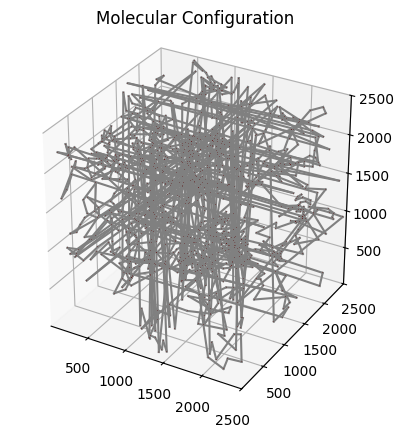

In [203]:
fig = plt.figure()
cpu_1000.set_step(-1)
ax = fig.add_subplot(111, projection='3d')
cpu_1000.plot(ax, size=0.002)

In [16]:
average_properties(cpu_1000.get_PE, cpu_1000.set_step, np.arange(90, 101))

np.float64(7302906326.111115)

In [17]:
segment_1000 = load_universe(box_size, k, epsilon_repulsive, "traj/n_1000.psf", "traj/segment_n_1000.xyz")
average_properties(segment_1000.get_PE, segment_1000.set_step, np.arange(90, 101))

np.float64(7302906350.722629)

In [18]:
cpu_pe = []
seg_pe = []
for step in tqdm(range(90, 101)):
  cpu_1000.set_step(step)
  cpu_pe.append(cpu_1000.get_PE())
  segment_1000.set_step(step)
  seg_pe.append(segment_1000.get_PE())

  0%|          | 0/11 [00:00<?, ?it/s]

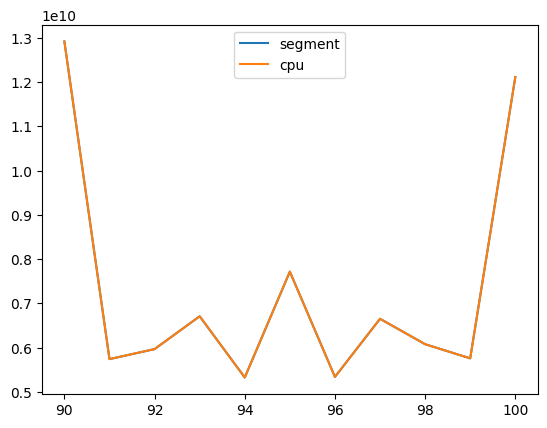

In [19]:
fig, ax = plt.subplots()
x = np.arange(90, 101)
ax.plot(x, seg_pe, label='segment')
ax.plot(x, cpu_pe, label='cpu')
ax.legend()

In [12]:
import MDAnalysis as mda
from MDAnalysis.transformations import unwrap, boxdimensions, center_in_box, wrap
from MDAnalysis.analysis.rdf import InterRDF
import nglview as nv
import time

In [13]:
def load_u(top, traj, box_size):
  u = mda.Universe(top, traj)
  dim = np.array([box_size, box_size, box_size, 90, 90, 90])
  set_box = boxdimensions.set_dimensions(dim)
  unwrap_mols = unwrap(u.atoms)
  centered = center_in_box(u.atoms)
  wrapped = wrap(u.atoms, compound='fragments')
  u.trajectory.add_transformations(set_box, unwrap_mols, centered, wrapped)
  return u

In [14]:
top = "traj/n_1000.psf"
box_size = 1000*2.5
universes = {
  "sequential": load_u(top, "traj/sequential_n_1000.xyz", box_size),
  "segmented": load_u(top, "traj/segment_n_1000.xyz", box_size),
  "explicit_matrix": load_u(top, "traj/force_matrix_explicit_n_1000.xyz", box_size),
  "implicit_matrix": load_u(top, "traj/force_matrix_explicit_n_1000.xyz", box_size),
  "cutoff_cpu": load_u(top, "traj/new_traces/cutoff_cpu_1000.xyz", box_size),
  "cutoff_sorted": load_u(top, "traj/new_traces/cutoff_sorted_gpu_1000.xyz", box_size),
  "cutoff_unsorted_gpu_1000": load_u(top, "traj/new_traces/cutoff_unsorted_gpu_1000.xyz", box_size)
}

c:\Users\repti\anaconda3\envs\chem-4050\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [16]:
rdf = {
  key: InterRDF(item.atoms, item.atoms, nbins=200, range=(0, box_size / 2.0), exclusion_block=(1, 1)).run(start=90, stop=100)
  for key, item in tqdm(universes.items())
}

  0%|          | 0/7 [00:00<?, ?it/s]

c:\Users\repti\anaconda3\envs\chem-4050\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\repti\anaconda3\envs\chem-4050\Lib\site-packages\MDAnalysis\analysis\base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


In [26]:
rdf_cpu_1000 = InterRDF(cpu_1000_u.atoms, cpu_1000_u.atoms, nbins=200, range=(0, box_size / 2.0), exclusion_block=(1, 1))
rdf_cpu_1000.run(start = 90, stop = 100)

/home/compute/chenglin.l/cse4059/CUDA_Molecular_Dynamics/.venv/lib/python3.12/site-packages/MDAnalysis/analysis/base.py:562: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


In [27]:
segment_1000_u = mda.Universe("traj/n_1000.psf", "traj/segment_n_1000.xyz")
dim = [box_size, box_size, box_size, 90.0, 90.0, 90.0]
transform = boxdimensions.set_dimensions(dim)
segment_1000_u.trajectory.add_transformations(transform)

In [28]:
rdf_segment_1000 = InterRDF(segment_1000_u.atoms, segment_1000_u.atoms , nbins=200, range=(0, box_size / 2.0), exclusion_block=(1, 1))
rdf_segment_1000.run(start = 90, stop = 100)

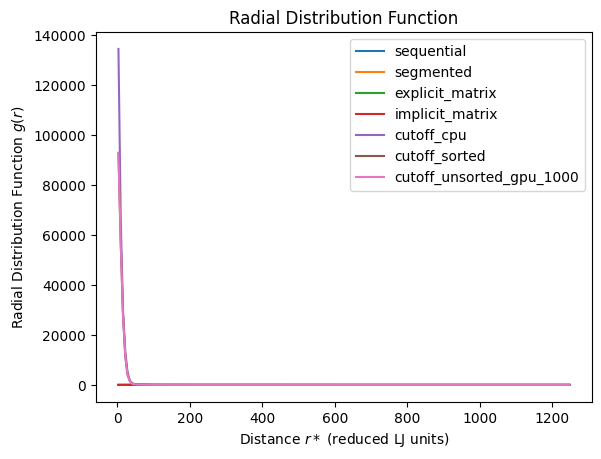

In [17]:
fig, ax = plt.subplots()
for key, item in rdf.items():
  ax.plot(item.results.bins, item.results.rdf, label=key)

ax.set_xlabel('Distance $r*$ (reduced LJ units)')
ax.set_ylabel('Radial Distribution Function $g(r)$')
ax.set_title('Radial Distribution Function')
ax.legend()